## Here we understand how can we use inmemory current state of the workflow

In [10]:
from typing import TypedDict,Annotated
from dotenv import  load_dotenv
from langgraph.graph import StateGraph,START,END
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage,BaseMessage
from langgraph.checkpoint.memory import InMemorySaver
from pprint import pprint

In [3]:
load_dotenv()
llm=ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite-preview")

In [4]:
class JokeState(TypedDict):
    topic:str
    joke:str
    explanation:str

In [5]:
def generate_joke(state:JokeState):
    prompt=f"""Generate me Joke on The Following Topic {state["topic"]}"""
    response_content=llm.invoke(prompt).content
    
    return {'joke':response_content}

def generate_explanation(state:JokeState):
    prompt=f"""Generate me explaination for the following joke {state["joke"]}"""
    response_explanation=llm.invoke(prompt).content
    
    return {"explanation":response_explanation}

In [6]:
# Define The Graph
graph=StateGraph(JokeState)

# Add The Nodes
graph.add_node("generate_joke",generate_joke)
graph.add_node("generate_explanation",generate_explanation)

# Add The Edges
graph.add_edge(START,"generate_joke")
graph.add_edge("generate_joke","generate_explanation")
graph.add_edge("generate_explanation",END)

# Defining The CheckPointer(This is a must Step for The State saving before executing each node) 
checkpointer=InMemorySaver()

# Compile The Graph
workflow=graph.compile(checkpointer=checkpointer)

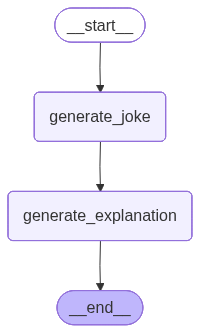

In [7]:
workflow

In [8]:
# Defining The Config
config={"configurable":{"thread_id":"1"}}
workflow.invoke({'topic':"pizza"},config=config)

{'topic': 'pizza',
 'joke': [{'type': 'text',
   'text': 'Why does pizza have such a hard time making friends?\n\nBecause it’s too **cheesy** and always ends up getting **burned**!',
   'extras': {'signature': 'EjQKMgEMOdbHlUR6BT9LvGtpz109ryk6JXK2srOy2Mus+HAnmx39GJZ/w+78sWRDL/vIFwx3'}}],
 'explanation': [{'type': 'text',
   'text': 'This joke relies on a **double entendre** (a play on words) where two culinary terms are used to describe social behavior. Here is the breakdown of why it’s funny:\n\n**1. The Pun on "Cheesy"**\n*   **Literal meaning:** A pizza is covered in melted cheese.\n*   **Figurative meaning:** In slang, calling someone or something "cheesy" means they are awkward, unfashionable, or trying too hard (like telling bad jokes or being overly sentimental). By saying the pizza is "too cheesy," the joke implies the pizza has an annoying personality that pushes people away.\n\n**2. The Pun on "Burned"**\n*   **Literal meaning:** If you leave a pizza in the oven for too long,

In [14]:
workflow.get_state(config=config)

StateSnapshot(values={'topic': 'pizza', 'joke': [{'type': 'text', 'text': 'Why does pizza have such a hard time making friends?\n\nBecause it’s too **cheesy** and always ends up getting **burned**!', 'extras': {'signature': 'EjQKMgEMOdbHlUR6BT9LvGtpz109ryk6JXK2srOy2Mus+HAnmx39GJZ/w+78sWRDL/vIFwx3'}}], 'explanation': [{'type': 'text', 'text': 'This joke relies on a **double entendre** (a play on words) where two culinary terms are used to describe social behavior. Here is the breakdown of why it’s funny:\n\n**1. The Pun on "Cheesy"**\n*   **Literal meaning:** A pizza is covered in melted cheese.\n*   **Figurative meaning:** In slang, calling someone or something "cheesy" means they are awkward, unfashionable, or trying too hard (like telling bad jokes or being overly sentimental). By saying the pizza is "too cheesy," the joke implies the pizza has an annoying personality that pushes people away.\n\n**2. The Pun on "Burned"**\n*   **Literal meaning:** If you leave a pizza in the oven for

In [15]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': [{'type': 'text',
   'text': 'Why did the pasta go to the doctor?\n\nBecause it was feeling **cannelloni**!',
   'extras': {'signature': 'EjQKMgEMOdbHNYpbN7I93geFk6rmHI7o4OLNys7BBHXH85A5sNyC1UgLFh1EzmRGtSsV+zyA'}}],
 'explanation': [{'type': 'text',
   'text': 'This joke is a play on words (a pun) that relies on the phonetic similarity between two phrases:\n\n1.  **"Cannelloni"**: A type of pasta consisting of cylindrical shells, usually served baked with a filling.\n2.  **"Can only" (sounded like "can-a-loni")**: A phrase used to express a state of being or a limited action.\n\n**The breakdown:**\n*   When someone asks, "How are you feeling?", a common response is, "I\'m feeling [adjective]." \n*   The joke setup asks why the pasta went to the doctor, implying it was "feeling" something.\n*   The punchline swaps "can only" with the word "cannelloni" to create a pun that sounds like the pasta is "feeling cannelloni" (which sounds like it’s saying, "I\'m feel

In [17]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'topic': 'pizza', 'joke': [{'type': 'text', 'text': 'Why does pizza have such a hard time making friends?\n\nBecause it’s too **cheesy** and always ends up getting **burned**!', 'extras': {'signature': 'EjQKMgEMOdbHlUR6BT9LvGtpz109ryk6JXK2srOy2Mus+HAnmx39GJZ/w+78sWRDL/vIFwx3'}}], 'explanation': [{'type': 'text', 'text': 'This joke relies on a **double entendre** (a play on words) where two culinary terms are used to describe social behavior. Here is the breakdown of why it’s funny:\n\n**1. The Pun on "Cheesy"**\n*   **Literal meaning:** A pizza is covered in melted cheese.\n*   **Figurative meaning:** In slang, calling someone or something "cheesy" means they are awkward, unfashionable, or trying too hard (like telling bad jokes or being overly sentimental). By saying the pizza is "too cheesy," the joke implies the pizza has an annoying personality that pushes people away.\n\n**2. The Pun on "Burned"**\n*   **Literal meaning:** If you leave a pizza in the oven fo

### Time Travel

In [18]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f1498d6-7311-6bdb-8000-0efd2509a53f"}})

StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f1498d6-7311-6bdb-8000-0efd2509a53f'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-05-06T20:51:49.568382+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1498d6-730d-6e25-bfff-21c15454b4a4'}}, tasks=(PregelTask(id='14bcc1fe-81d4-2bad-2fed-ada080276509', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': [{'type': 'text', 'text': 'Why does pizza have such a hard time making friends?\n\nBecause it’s too **cheesy** and always ends up getting **burned**!', 'extras': {'signature': 'EjQKMgEMOdbHlUR6BT9LvGtpz109ryk6JXK2srOy2Mus+HAnmx39GJZ/w+78sWRDL/vIFwx3'}}]}),), interrupts=())

In [19]:
# running the workflow from a particular point
workflow.invoke(None,{"configurable": {"thread_id": "1", "checkpoint_id": "1f1498d6-7311-6bdb-8000-0efd2509a53f"}})

{'topic': 'pizza',
 'joke': [{'type': 'text',
   'text': 'Why was the pizza maker so sad?\n\nBecause he couldn’t make **ends meat**.',
   'extras': {'signature': 'EjQKMgEMOdbHgPRu2+F2FWs0MGcTi1qIJOUxDPMQfArueWXg+oGcfhQ9G3amRGQ58HQNMhSP'}}],
 'explanation': [{'type': 'text',
   'text': 'This joke is a play on words based on a common English idiom. Here is the breakdown of why it works:\n\n**1. The Idiom:**\nThe phrase **"making ends meet"** is a standard expression that means earning enough money to cover one\'s basic living expenses. If someone is "having trouble making ends meet," it means they are struggling financially.\n\n**2. The Pun:**\nThe pizza maker is "sad" because he cannot "make **ends meat**." In the context of a pizza maker, "meat" refers to the toppings (like pepperoni, sausage, or ham) that go on a pizza. By changing the word "meet" to "meat," the joke creates a double meaning:\n*   **The literal meaning:** He is unable to put meat on the edges (the "ends" or the crust)

In [20]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'topic': 'pizza', 'joke': [{'type': 'text', 'text': 'Why was the pizza maker so sad?\n\nBecause he couldn’t make **ends meat**.', 'extras': {'signature': 'EjQKMgEMOdbHgPRu2+F2FWs0MGcTi1qIJOUxDPMQfArueWXg+oGcfhQ9G3amRGQ58HQNMhSP'}}], 'explanation': [{'type': 'text', 'text': 'This joke is a play on words based on a common English idiom. Here is the breakdown of why it works:\n\n**1. The Idiom:**\nThe phrase **"making ends meet"** is a standard expression that means earning enough money to cover one\'s basic living expenses. If someone is "having trouble making ends meet," it means they are struggling financially.\n\n**2. The Pun:**\nThe pizza maker is "sad" because he cannot "make **ends meat**." In the context of a pizza maker, "meat" refers to the toppings (like pepperoni, sausage, or ham) that go on a pizza. By changing the word "meet" to "meat," the joke creates a double meaning:\n*   **The literal meaning:** He is unable to put meat on the edges (the "ends" or

### Updating State

In [21]:
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f1498d6-7311-6bdb-8000-0efd2509a53f", "checkpoint_ns": ""}}, {'topic':'samosa'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f14990e-ffd8-6682-8001-ecfbbb25cd5f'}}

In [22]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f14990e-ffd8-6682-8001-ecfbbb25cd5f'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-05-06T21:17:07.568357+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1498d6-7311-6bdb-8000-0efd2509a53f'}}, tasks=(PregelTask(id='bd1af2b2-a84b-576d-9c0c-6c7fcc19a709', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': [{'type': 'text', 'text': 'Why was the pizza maker so sad?\n\nBecause he couldn’t make **ends meat**.', 'extras': {'signature': 'EjQKMgEMOdbHgPRu2+F2FWs0MGcTi1qIJOUxDPMQfArueWXg+oGcfhQ9G3amRGQ58HQNMhSP'}}], 'explanation': [{'type': 'text', 'text': 'This joke is a play on words based on a common English idiom. Here is the breakdow

In [23]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f14990e-ffd8-6682-8001-ecfbbb25cd5f"}})

{'topic': 'samosa',
 'joke': [{'type': 'text',
   'text': 'Why did the samosa go to the doctor?\n\nBecause he was feeling a little **stuffed** and his **filling** was all over the place!',
   'extras': {'signature': 'EjQKMgEMOdbH48FgrykLIym5GmdB+PlLIBeqtbJcxv5LKRXE7ZTDNB5e/yOYADC71M/E0DXj'}}],
 'explanation': [{'type': 'text',
   'text': 'This joke is a play on words (a pun) that relies on the dual meanings of words related to food and health. Here is the breakdown:\n\n**1. The context of a "Samosa":**\nA samosa is a popular Indian snack, which is a fried pastry typically **stuffed** with a savory **filling** (usually potatoes, peas, or meat).\n\n**2. The double meanings:**\n*   **"Stuffed":** In the context of food, it refers to the ingredients inside the pastry. In the context of a person feeling sick, it means feeling overly full or bloated after eating too much.\n*   **"Filling":** In the context of a samosa, it is the physical stuffing inside the pastry. In the context of a person

In [24]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'topic': 'samosa', 'joke': [{'type': 'text', 'text': 'Why did the samosa go to the doctor?\n\nBecause he was feeling a little **stuffed** and his **filling** was all over the place!', 'extras': {'signature': 'EjQKMgEMOdbH48FgrykLIym5GmdB+PlLIBeqtbJcxv5LKRXE7ZTDNB5e/yOYADC71M/E0DXj'}}], 'explanation': [{'type': 'text', 'text': 'This joke is a play on words (a pun) that relies on the dual meanings of words related to food and health. Here is the breakdown:\n\n**1. The context of a "Samosa":**\nA samosa is a popular Indian snack, which is a fried pastry typically **stuffed** with a savory **filling** (usually potatoes, peas, or meat).\n\n**2. The double meanings:**\n*   **"Stuffed":** In the context of food, it refers to the ingredients inside the pastry. In the context of a person feeling sick, it means feeling overly full or bloated after eating too much.\n*   **"Filling":** In the context of a samosa, it is the physical stuffing inside the pastry. In the context 